In [7]:
import os
import time
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.decomposition import PCA

import sys
sys.path.append('../src') # Чтобы ноутбук увидел папку src
from config import METHODS_DICT, DATASETS, RESULTS_PATH, get_paths
from data_loader import get_target_names, get_ag_news, get_imdb
from visualizer import get_pca_plot, get_confusion_matrix_plot, get_classification_report_df

In [8]:
# DATASET_NAME = "20 Newsgroups"
# DATASET_NAME = "AG News"
DATASET_NAME = "IMDB"
dataset_key = DATASETS[DATASET_NAME]["key"]

paths = get_paths(dataset_key)

VECTORS_PATH = paths["VECTORS"]
PLOTS_PATH = paths["PLOTS"]
TABLES_PATH = paths["TABLES"]
PRED_PATH = paths["PRED"]
MODELS_PATH = paths["MODELS"]
print(f"📊 Работаем с датасетом: {DATASET_NAME}")
print("Папки с которыми работаем")
print(VECTORS_PATH)
print(PLOTS_PATH)
print(TABLES_PATH)
print(PRED_PATH)
print(MODELS_PATH)

📊 Работаем с датасетом: IMDB
Папки с которыми работаем
D:\PythonProj\Diplom_v2\data\processed/imdb
D:\PythonProj\Diplom_v2\results\plots/imdb
D:\PythonProj\Diplom_v2\results\tables/imdb
D:\PythonProj\Diplom_v2\results\predictions/imdb
D:\PythonProj\Diplom_v2\data\models/imdb


In [9]:
# пути
# BASE_PATH = "../"
# VECTORS_PATH = os.path.join(BASE_PATH, "data/processed")
# RESULTS_PATH = os.path.join(BASE_PATH, "results")
# PLOTS_PATH = os.path.join(RESULTS_PATH, "plots")
# TABLES_PATH = os.path.join(RESULTS_PATH, "tables")
# PRED_PATH = os.path.join(RESULTS_PATH, "predictions")
# MODELS_PATH = os.path.join(BASE_PATH, "data/models")

os.makedirs(PLOTS_PATH, exist_ok=True)
os.makedirs(TABLES_PATH, exist_ok=True)
os.makedirs(PRED_PATH, exist_ok=True)
os.makedirs(MODELS_PATH, exist_ok=True)

# методы
# methods = [
#     ("Binary", "binary"),
#     ("Bag of Words", "bow"),
#     ("TF-IDF Standard", "tfidf_std"),
#     ("TF-IDF Bigrams", "tfidf_bigrams"),
#     ("Word2Vec", "w2v"),
#     ("Doc2Vec", "d2v"),
#     ("BERT", "bert")
# ]
# methods = {
#     "Binary": "binary",
#     "Bag of Words": "bow",
#     "TF-IDF Standard": "tfidf_std",
#     "TF-IDF Bigrams": "tfidf_bigrams",
#     "Word2Vec": "w2v",
#     "Doc2Vec": "d2v",
#     "BERT": "bert"
# }

In [10]:
# загрузка данных
y_train = np.load(f"{VECTORS_PATH}/y_train.npy")
y_test = np.load(f"{VECTORS_PATH}/y_test.npy")

with open(f"{VECTORS_PATH}/vectorization_time.json", "r") as f:
    v_times = json.load(f)


In [11]:
# итоговый цикл
results = []
for name, key in METHODS_DICT.items():
    print(f"{name}")

    # --- загрузка векторов ---
    X_train = np.load(f"{VECTORS_PATH}/train_{key}_vectors.npy")
    X_test = np.load(f"{VECTORS_PATH}/test_{key}_vectors.npy")

    # --- модель ---
    start = time.time()
    model = LogisticRegression(max_iter=1000, random_state=42)

    model.fit(X_train, y_train)

    # --- предсказание ---
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    train_time = round(time.time() - start, 2)

    # --- сохраняем предсказания ---
    np.save(f"{PRED_PATH}/{key}_y_pred.npy", y_pred)

    # --- сохраняем модель ---
    joblib.dump(model, f"{MODELS_PATH}/{key}_model.pkl")

    # --- сохраняем метрики ---
    results.append({
        "Method": name,
        "Vectorization Time": v_times[key],
        "Training Time": train_time,
        "Total Time": v_times[key] + train_time,
        "Accuracy": acc
    })


Binary
Bag of Words
TF-IDF Standard
TF-IDF Bigrams
Word2Vec
Doc2Vec
BERT


In [12]:
# Создаем красивый отчет
df_detailed = pd.DataFrame(results).sort_values(by = "Accuracy", ascending = False)
print(df_detailed)

            Method  Vectorization Time  Training Time   Total Time  Accuracy
2  TF-IDF Standard            5.180353           2.44     7.620353    0.8857
3   TF-IDF Bigrams           15.046727           2.41    17.456727    0.8855
1     Bag of Words            5.033095          10.15    15.183095    0.8753
0           Binary            6.015279           5.77    11.785279    0.8694
5          Doc2Vec          276.475770           0.25   276.725770    0.8350
4         Word2Vec           34.808663           0.65    35.458663    0.8276
6             BERT         1797.389944           0.69  1798.079944    0.8185


In [13]:
df_detailed.to_csv(f"{TABLES_PATH}/classification_compare.csv", index = False)
print(f"Результаты сохранены в {TABLES_PATH}/classification_compare.csv")

Результаты сохранены в D:\PythonProj\Diplom_v2\results\tables/imdb/classification_compare.csv


In [14]:
# Выбираем топ два метода
df_detailed= pd.read_csv(f"{TABLES_PATH}/classification_compare.csv")
top_methods = df_detailed.head(2)["Method"].values
with open(f"{RESULTS_PATH}/{dataset_key}_top_methods_classification.json", "w") as f:
    json.dump(list(top_methods), f)
print("TOP METHODS:")
for m in top_methods:
    print(m)

TOP METHODS:
TF-IDF Standard
TF-IDF Bigrams


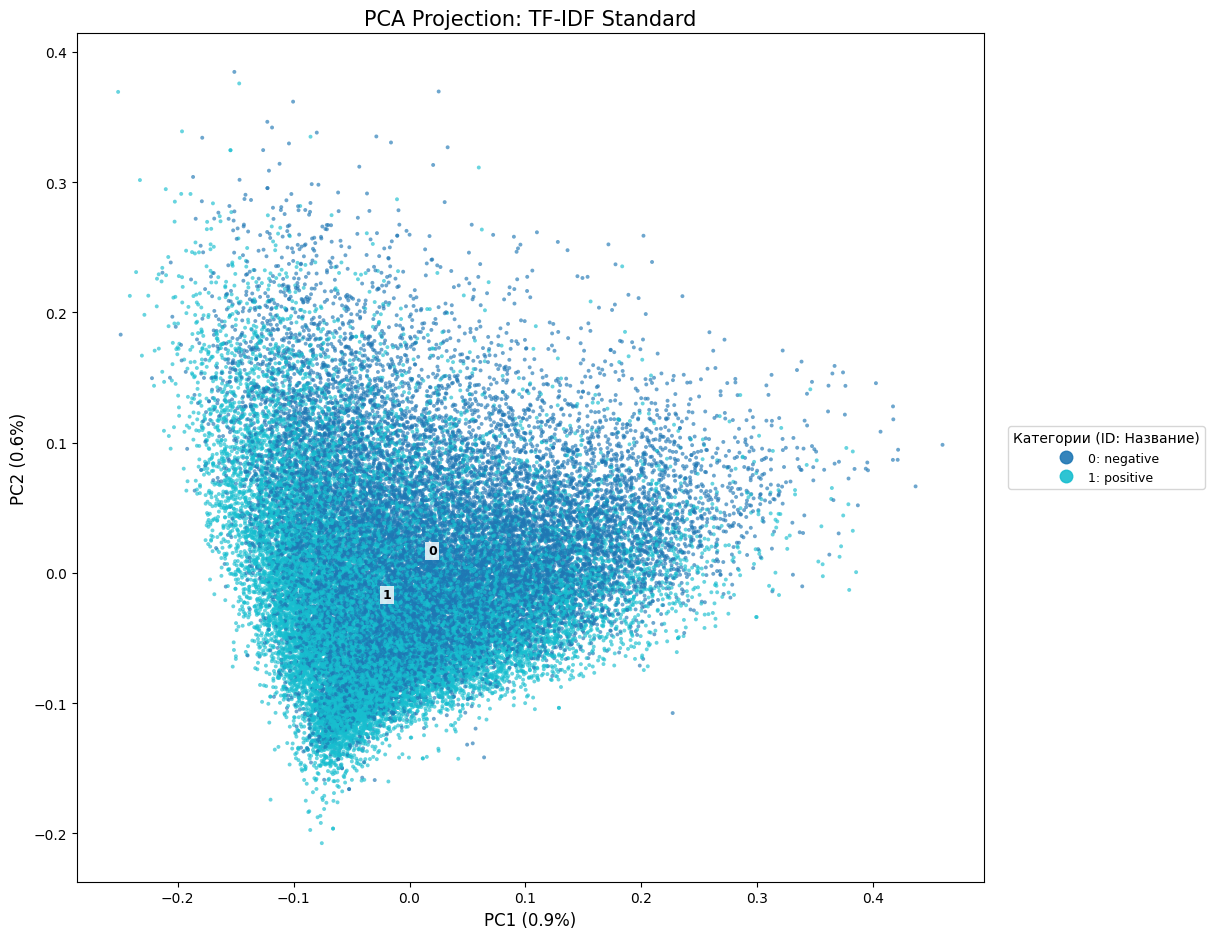

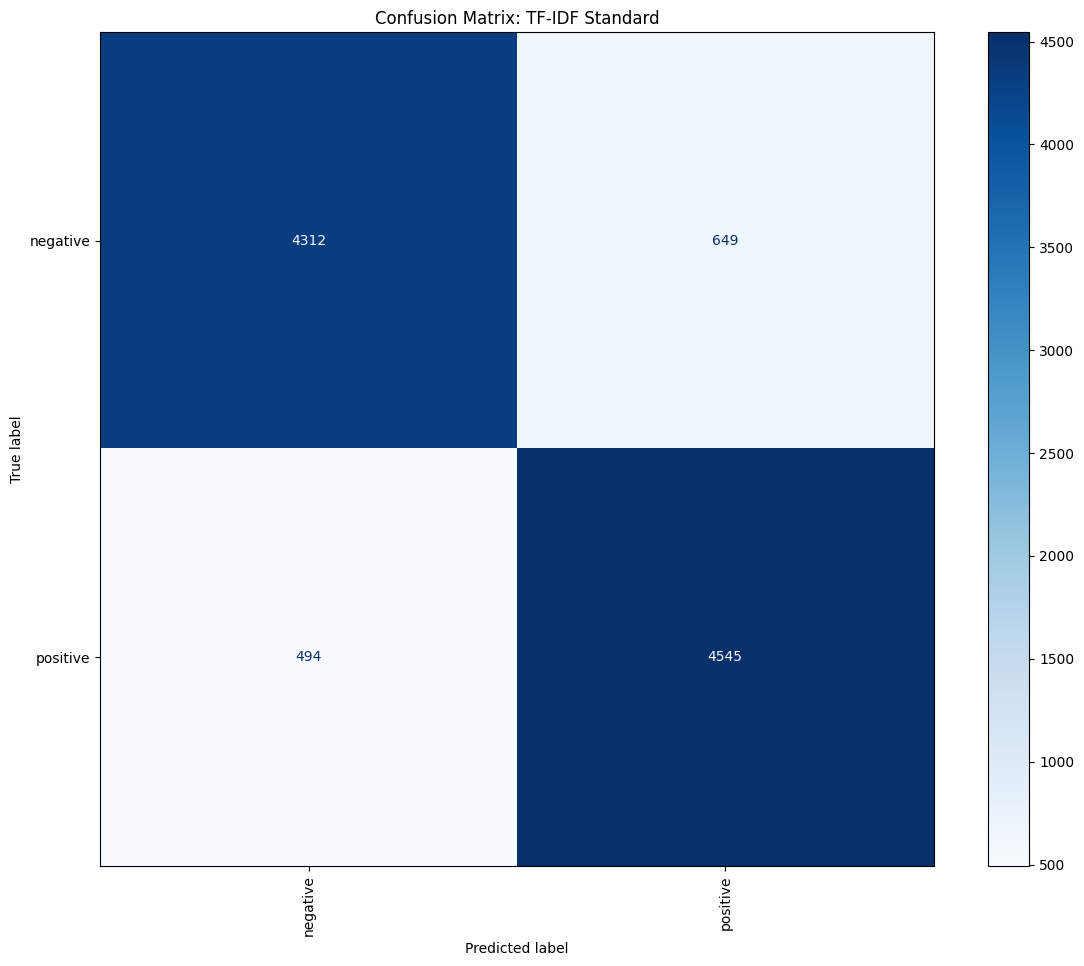

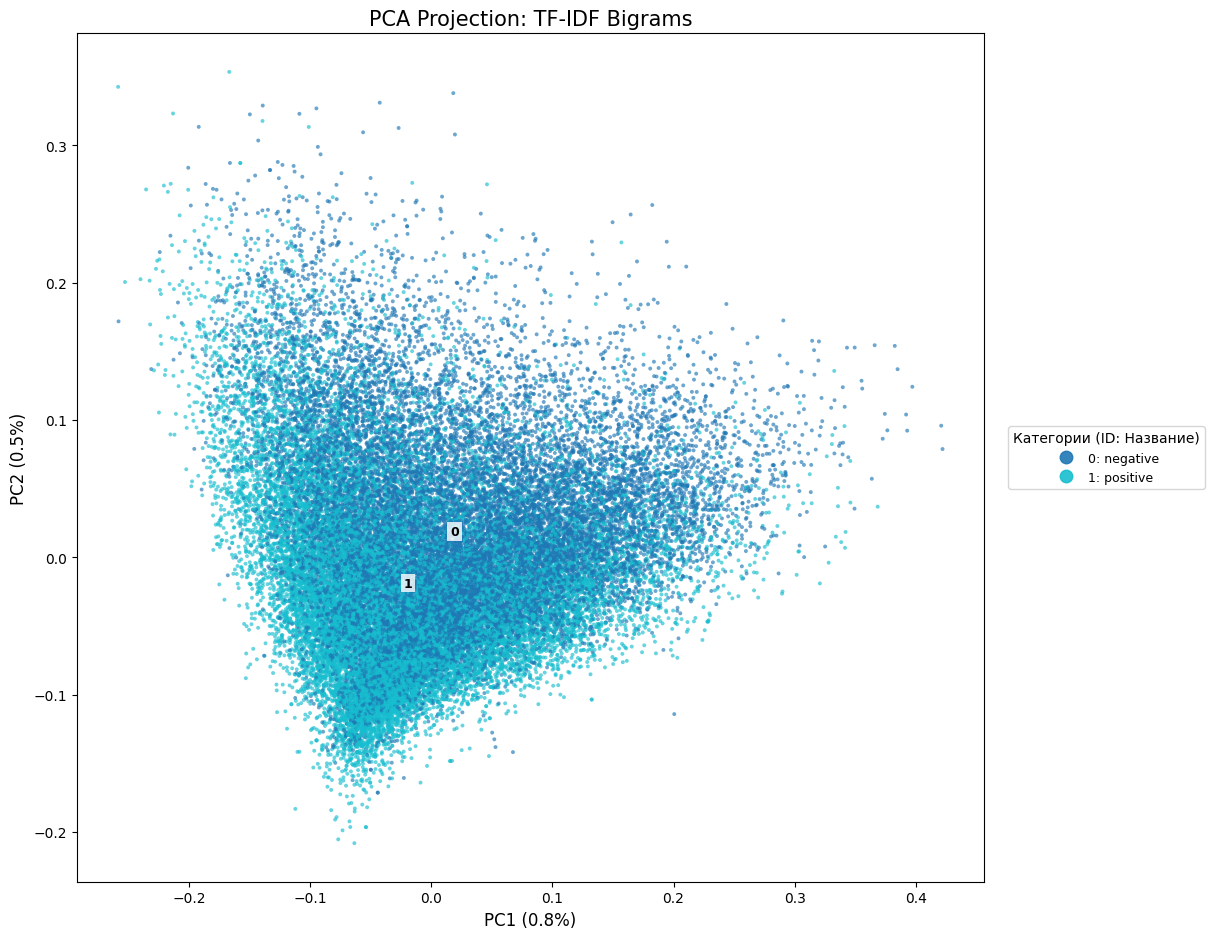

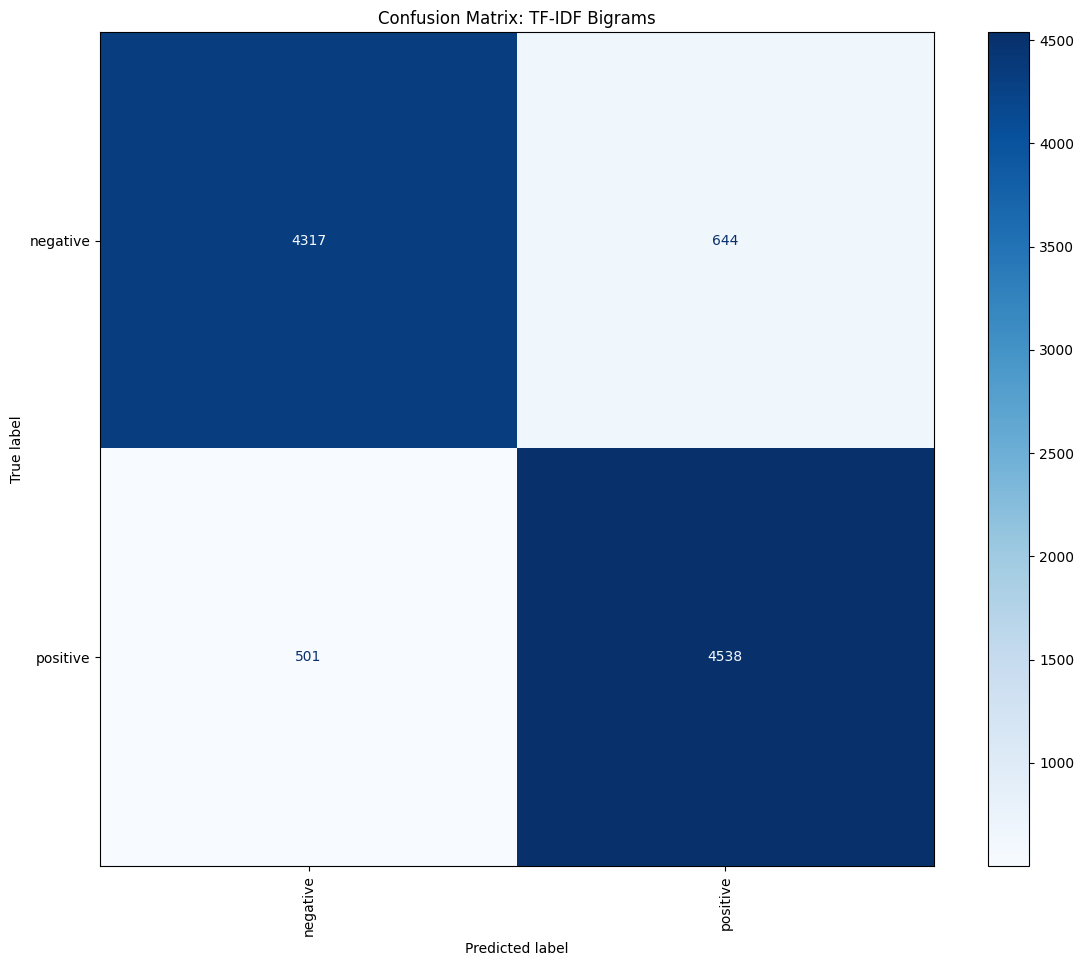

In [15]:
# Получаем имена категорий одной командой
target_names = get_target_names(dataset_key)
# Проходим только по ТОП-2
for name in top_methods:
    key = METHODS_DICT[name]
    
    # Загружаем данные (они в памяти только пока идет цикл)
    X_train = np.load(f"{VECTORS_PATH}/train_{key}_vectors.npy")
    y_pred = np.load(f"{PRED_PATH}/{key}_y_pred.npy")
    
    # Вызываем функции из нашего файла
    fig1 = get_pca_plot(X_train, y_train, target_names, name)
    plt.savefig(f"{PLOTS_PATH}/pca_{key}.png", dpi=300, bbox_inches='tight')
    plt.show() # В ноутбуке используем plt.show()
    
    fig2 = get_confusion_matrix_plot(y_test, y_pred, target_names, name)
    plt.savefig(f"{PLOTS_PATH}/confusion_matrix_{key}.png", dpi=300)
    plt.show()

    report = get_classification_report_df(y_test, y_pred, target_names)
    report.to_csv(f"{TABLES_PATH}/classification_report_{key}.csv")
    # Чистим память после каждого метода
    del X_train, y_pred

In [33]:
df = pd.read_csv("../data/raw/imdb/imdb.csv")
# df.isnull().sum()
print(df.tail(20))
df.info()
# очистка текста
df["review"] = df["review"].str.replace("<br />", " ", regex=False)
print(df.tail(20))
df.info()
# удаляем пустые значения
df = df.dropna()

df = df[df["review"].str.strip() != ""]
print(df.tail(20))
df["sentiment"].unique()
# метки
# df.isnull().sum()
# df['text'].apply(lambda x: len(str(x))).describe()
# df['label'].unique()

                                                  review sentiment
49980  A stunning film of high quality.<br /><br />Ap...  positive
49981  And I repeat, please do not see this movie! Th...  negative
49982  To be hones, I used to like this show and watc...  negative
49983  I loved it, having been a fan of the original ...  positive
49984  Hello it is I Derrick Cannon and I welcome you...  negative
49985  Imaginary Heroes is clearly the best film of t...  positive
49986  This movie is a disgrace to the Major League F...  negative
49987  A remake of Alejandro Amenabar's Abre los Ojos...  negative
49988  When I first tuned in on this morning news, I ...  negative
49989  I got this one a few weeks ago and love it! It...  positive
49990  Lame, lame, lame!!! A 90-minute cringe-fest th...  negative
49991  Les Visiteurs, the first movie about the medie...  negative
49992  John Garfield plays a Marine who is blinded by...  positive
49993  Robert Colomb has two full-time jobs. He's kno...  nega

<ArrowStringArray>
['positive', 'negative']
Length: 2, dtype: str

In [31]:
train_df = pd.read_csv("../data/raw/ag_news/train.csv")
test_df = pd.read_csv("../data/raw/ag_news/test.csv")

df = pd.concat([train_df, test_df], ignore_index=True)
df.info()
# df.head(20)
df["text"] = df["Title"] + " " + df["Description"]
df["label"] = df["Class Index"] - 1
df.head(20)
df.info()
df.head(20)
df["label"].unique()
df["text"].unique()
# df = df.dropna()
# df = df[df["text"].str.strip() != ""]

<class 'pandas.DataFrame'>
RangeIndex: 127600 entries, 0 to 127599
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype
---  ------       --------------   -----
 0   Class Index  127600 non-null  int64
 1   Title        127600 non-null  str  
 2   Description  127600 non-null  str  
dtypes: int64(1), str(2)
memory usage: 31.6 MB
<class 'pandas.DataFrame'>
RangeIndex: 127600 entries, 0 to 127599
Data columns (total 5 columns):
 #   Column       Non-Null Count   Dtype
---  ------       --------------   -----
 0   Class Index  127600 non-null  int64
 1   Title        127600 non-null  str  
 2   Description  127600 non-null  str  
 3   text         127600 non-null  str  
 4   label        127600 non-null  int64
dtypes: int64(2), str(3)
memory usage: 62.3 MB


<ArrowStringArray>
[                                                                                                                                                                                                                                                                              'Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.',
                                                                                                                                                     'Carlyle Looks Toward Commercial Aerospace (Reuters) Reuters - Private investment firm Carlyle Group,\which has a reputation for making well-timed and occasionally\controversial plays in the defense industry, has quietly placed\its bets on another part of the market.',
                                                                                                                                               